The **feature columns** in this dataset represent **EEG (Electroencephalogram) signals** recorded from different locations on the scalp.

---

## What do the feature columns represent?

Each feature (column) corresponds to the **electrical activity of the brain** measured at a specific **EEG electrode**, following the **international 10–20 system**.

### EEG Feature Columns

| Column | Brain region             | What it represents         |
| ------ | ------------------------ | -------------------------- |
| AF3    | Anterior frontal (left)  | Attention, focus           |
| AF4    | Anterior frontal (right) | Attention, decision making |
| F3     | Frontal (left)           | Thinking, memory           |
| F4     | Frontal (right)          | Cognitive control          |
| F7     | Frontal lateral (left)   | Emotion processing         |
| F8     | Frontal lateral (right)  | Emotion processing         |
| FC5    | Fronto-central (left)    | Motor planning             |
| FC6    | Fronto-central (right)   | Motor planning             |
| T7     | Temporal (left)          | Auditory processing        |
| T8     | Temporal (right)         | Auditory processing        |
| P7     | Parietal (left)          | Spatial awareness          |
| P8     | Parietal (right)         | Spatial awareness          |
| O1     | Occipital (left)         | Visual processing          |
| O2     | Occipital (right)        | Visual processing          |

---

## What about `eyeDetection`?

* It is **not a feature**
* It is the **target (label)**
* It indicates the eye state:

  * `0` → Eyes open
  * `1` → Eyes closed

---

## Short academic description (for reports)

> The feature columns consist of EEG signals acquired from 14 scalp electrodes distributed across frontal, temporal, parietal, and occipital brain regions. The `eyeDetection` column represents the target variable used to classify eye state (open or closed).

---



**Import Tools**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use("dark_background")
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


**Load Dataset**

In [2]:
data = pd.read_csv("/kaggle/input/eeg-eye-state-detection-dataset/EEG-Eye-State.csv")
data.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03,0
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97,0
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26,0
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77,0
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69,0


In [3]:
columns = data.columns
print(f"Dataset Columns: {list(columns)}")
print(f"Dataset Contain {data.shape[0]} Rows and {data.shape[1]} Columns")

Dataset Columns: ['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7', 'P8', 'O1', 'O2', 'eyeDetection']
Dataset Contain 14980 Rows and 15 Columns


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   AF4           14980 non-null  float64
 2   F3            14980 non-null  float64
 3   F4            14980 non-null  float64
 4   F7            14980 non-null  float64
 5   F8            14980 non-null  float64
 6   FC5           14980 non-null  float64
 7   FC6           14980 non-null  float64
 8   T7            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  P7            14980 non-null  float64
 11  P8            14980 non-null  float64
 12  O1            14980 non-null  float64
 13  O2            14980 non-null  float64
 14  eyeDetection  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB


In [5]:
data.isnull().sum()

AF3             0
AF4             0
F3              0
F4              0
F7              0
F8              0
FC5             0
FC6             0
T7              0
T8              0
P7              0
P8              0
O1              0
O2              0
eyeDetection    0
dtype: int64

In [6]:
data[data.duplicated()]

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection


In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
AF3,14980.0,4321.917777,2492.072174,1030.7700,4280.51,4294.36,4311.79,309231.00
AF4,14980.0,4416.435832,5891.285043,1366.1500,4342.05,4354.87,4372.82,715897.00
F3,14980.0,4264.022433,44.428052,1040.0000,4250.26,4262.56,4270.77,6880.51
F4,14980.0,4279.232774,41.544312,2257.9500,4267.69,4276.92,4287.18,7002.56
F7,14980.0,4009.767694,45.941672,2830.7700,3990.77,4005.64,4023.08,7804.62
F8,14980.0,4615.205336,1208.369958,86.6667,4590.77,4603.08,4617.44,152308.00
FC5,14980.0,4164.946326,5216.404632,2453.3300,4108.21,4120.51,4132.31,642564.00
FC6,14980.0,4202.456900,37.785981,3273.3300,4190.26,4200.51,4211.28,6823.08
T7,14980.0,4341.741075,34.738821,2089.7400,4331.79,4338.97,4347.18,6474.36
T8,14980.0,4231.316200,38.050903,1816.4100,4220.51,4229.23,4239.49,6674.36


**EDA**

In [8]:
for column in columns[:-1]:
    print(f"{column} | Min: {data[column].min():.2f} | Max: {data[column].max():.2f} | Median: {data[column].median():.2f}")
    print("-"*50)

AF3 | Min: 1030.77 | Max: 309231.00 | Median: 4294.36
--------------------------------------------------
AF4 | Min: 1366.15 | Max: 715897.00 | Median: 4354.87
--------------------------------------------------
F3 | Min: 1040.00 | Max: 6880.51 | Median: 4262.56
--------------------------------------------------
F4 | Min: 2257.95 | Max: 7002.56 | Median: 4276.92
--------------------------------------------------
F7 | Min: 2830.77 | Max: 7804.62 | Median: 4005.64
--------------------------------------------------
F8 | Min: 86.67 | Max: 152308.00 | Median: 4603.08
--------------------------------------------------
FC5 | Min: 2453.33 | Max: 642564.00 | Median: 4120.51
--------------------------------------------------
FC6 | Min: 3273.33 | Max: 6823.08 | Median: 4200.51
--------------------------------------------------
T7 | Min: 2089.74 | Max: 6474.36 | Median: 4338.97
--------------------------------------------------
T8 | Min: 1816.41 | Max: 6674.36 | Median: 4229.23
---------------------

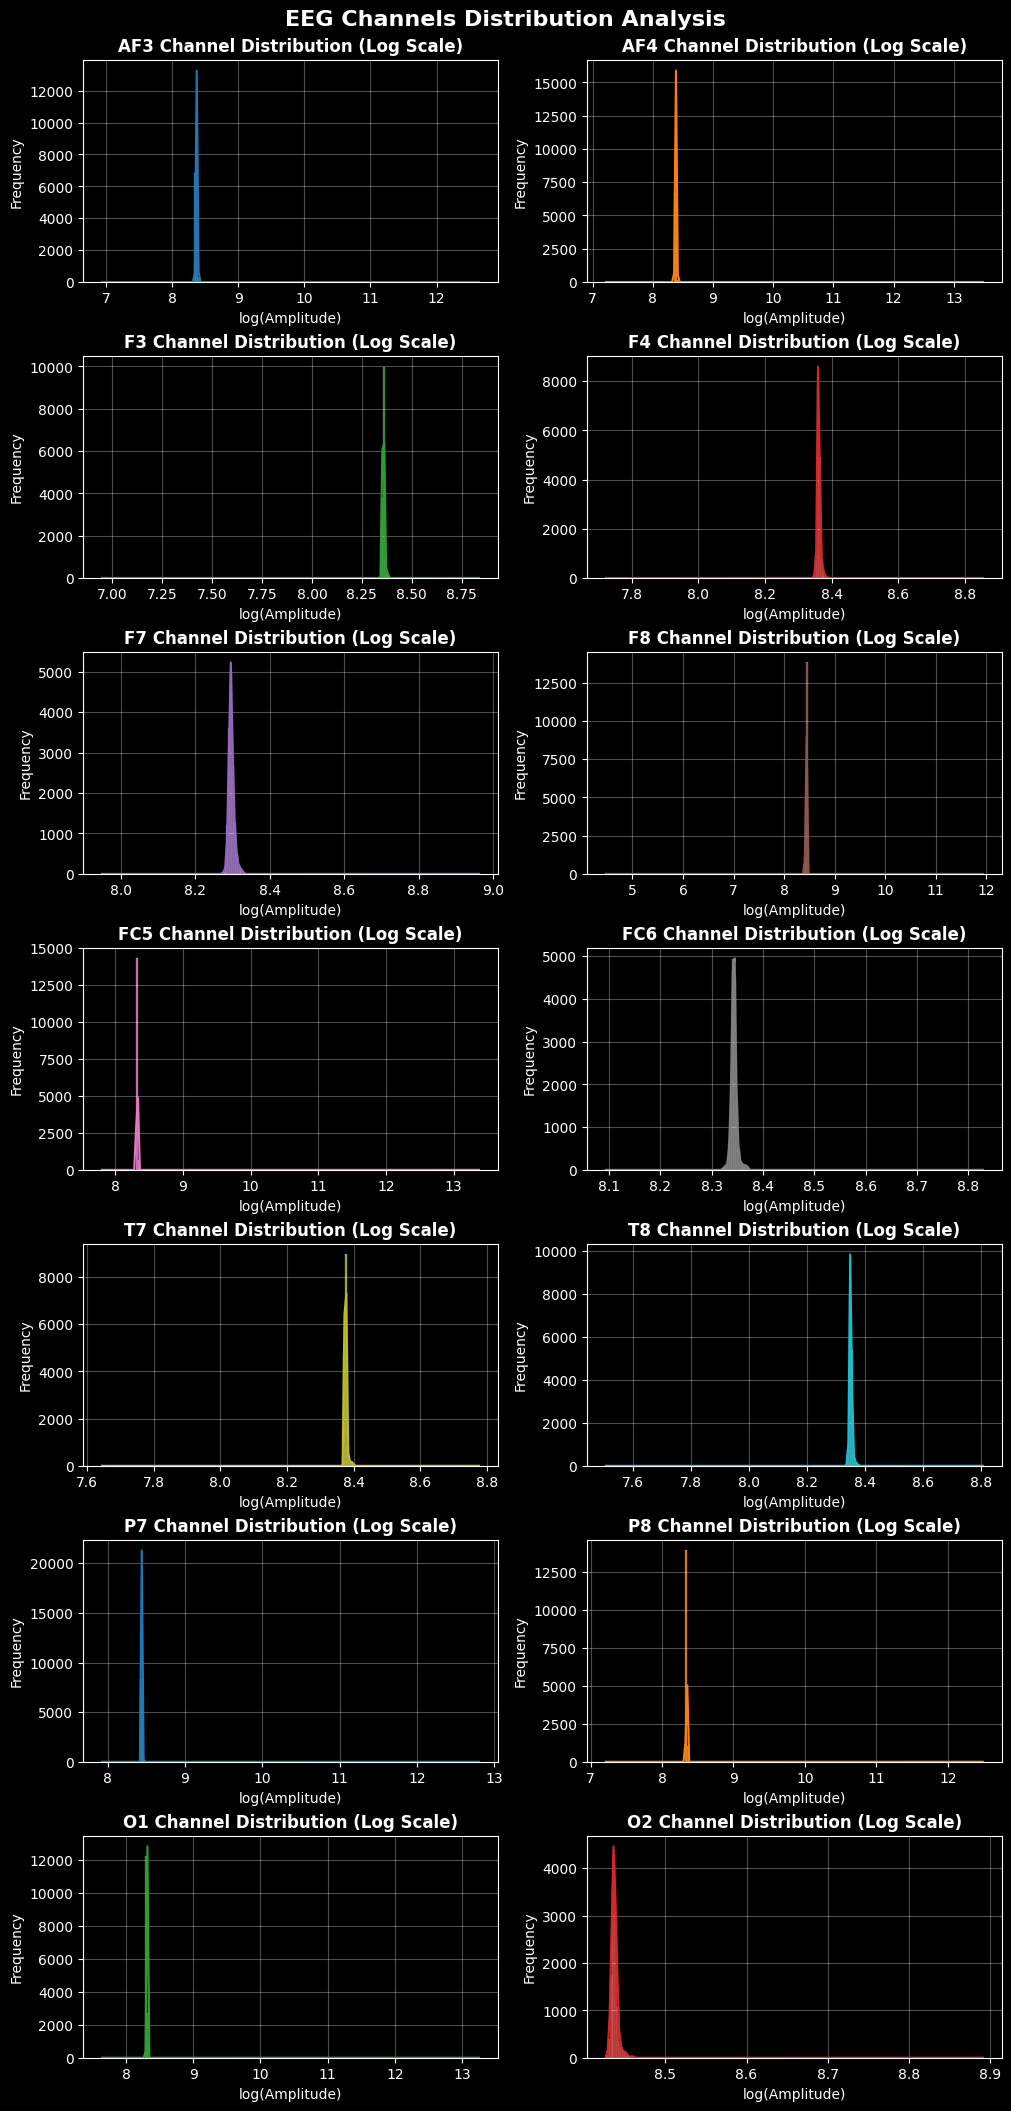

In [9]:
features = columns[:-1]
n_cols = 2
n_rows = (len(features) + n_cols - 1) // n_cols  
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(10, n_rows * 3),
    constrained_layout=True
)
axes = axes.flatten()
colors = sns.color_palette("tab10", len(features))
for i, column in enumerate(features):
    sns.histplot(
        x=np.log1p(data[column]),
        bins=200,
        kde=True,
        color=colors[i],
        alpha=0.85,
        ax=axes[i]
    )
    
    axes[i].set_title(
        f"{column} Channel Distribution (Log Scale)",
        fontsize=12,
        fontweight="bold"
    )
    axes[i].set_xlabel("log(Amplitude)")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle(
    "EEG Channels Distribution Analysis",
    fontsize=16,
    fontweight="bold"
)
plt.show()

In [10]:
stats = data.groupby("eyeDetection")[features].agg(
    ["mean", "median", "min", "max"]
)
stats


AF3                                       AF4           \
                     mean   median      min        max         mean   median   
eyeDetection                                                                   
0             4298.402552  4291.28  1030.77    7398.46  4456.567286  4352.31   
1             4350.798517  4297.95  4198.97  309231.00  4367.147507  4360.00   

                                           F3           ...       P8  \
                  min        max         mean   median  ...      min   
eyeDetection                                            ...            
0             1366.15  715897.00  4262.462922  4261.54  ...  1357.95   
1             4246.15    5022.56  4265.937779  4263.59  ...  4147.69   

                                  O1                               \
                    max         mean   median      min        max   
eyeDetection                                                        
0               7143.59  4140.387390  4070.77  3581.54  567179.00   
1             265641.00  4073.570684  4070.26  2086.15    4167.18   

                       O2                             
                     mean   median      min      max  
eyeDetection                                          
0             4615.393493  4612.82  4567.18  7264.10  
1             4616.871687  4614.87  4567.69  4770.26  

[2 rows x 56 columns]

In [11]:
for eye_state, group in data.groupby("eyeDetection"):
    print(f"\nEye State: {eye_state}")
    print("-" * 60)
    for col in features:
        print(
            f"{col:<4} | "
            f"Mean: {group[col].mean():.2f} | "
            f"Median: {group[col].median():.2f} | "
            f"Min: {group[col].min():.2f} | "
            f"Max: {group[col].max():.2f}"
        )


Eye State: 0
------------------------------------------------------------
AF3  | Mean: 4298.40 | Median: 4291.28 | Min: 1030.77 | Max: 7398.46
AF4  | Mean: 4456.57 | Median: 4352.31 | Min: 1366.15 | Max: 715897.00
F3   | Mean: 4262.46 | Median: 4261.54 | Min: 1040.00 | Max: 5762.56
F4   | Mean: 4277.43 | Median: 4274.87 | Min: 3091.28 | Max: 7002.56
F7   | Mean: 4013.08 | Median: 4007.18 | Min: 2830.77 | Max: 7804.62
F8   | Mean: 4600.90 | Median: 4601.03 | Min: 86.67 | Max: 4833.85
FC5  | Mean: 4200.39 | Median: 4121.03 | Min: 2453.33 | Max: 642564.00
FC6  | Mean: 4200.26 | Median: 4199.49 | Min: 3273.33 | Max: 6137.95
T7   | Mean: 4341.75 | Median: 4339.49 | Min: 2089.74 | Max: 6474.36
T8   | Mean: 4229.70 | Median: 4228.21 | Min: 1816.41 | Max: 6674.36
P7   | Mean: 4664.73 | Median: 4619.49 | Min: 2768.21 | Max: 362564.00
P8   | Mean: 4200.37 | Median: 4199.49 | Min: 1357.95 | Max: 7143.59
O1   | Mean: 4140.39 | Median: 4070.77 | Min: 3581.54 | Max: 567179.00
O2   | Mean: 4615.39 |

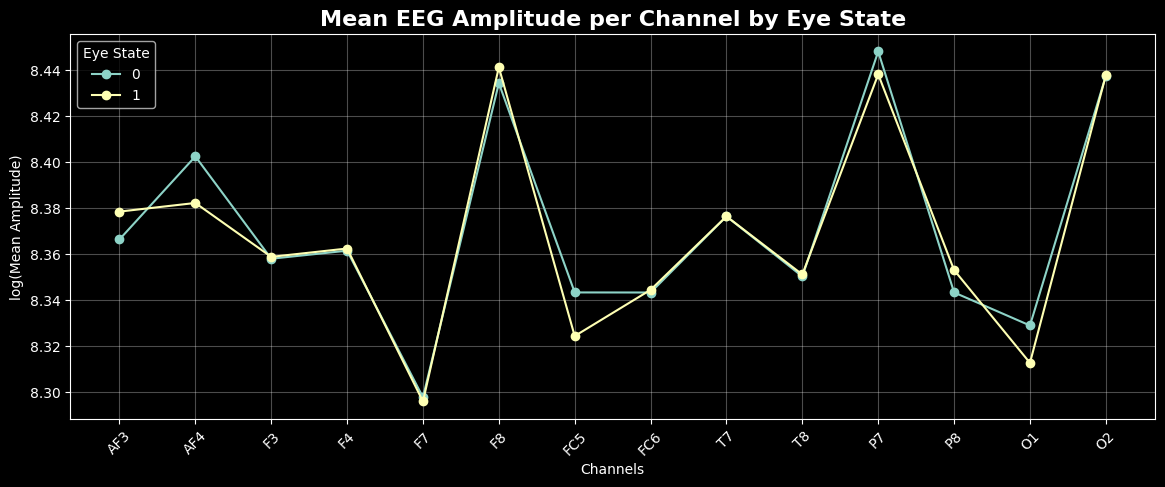

In [12]:
mean_by_state = data.groupby("eyeDetection")[features].mean()
plt.figure(figsize=(14, 5))
for state in mean_by_state.index:
    plt.plot(
        features,
        np.log1p(mean_by_state.loc[state]),
        marker="o",
        label=state
    )
plt.title("Mean EEG Amplitude per Channel by Eye State", fontsize=16, fontweight="bold")
plt.xlabel("Channels")
plt.ylabel("log(Mean Amplitude)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.legend(title="Eye State")
plt.show()

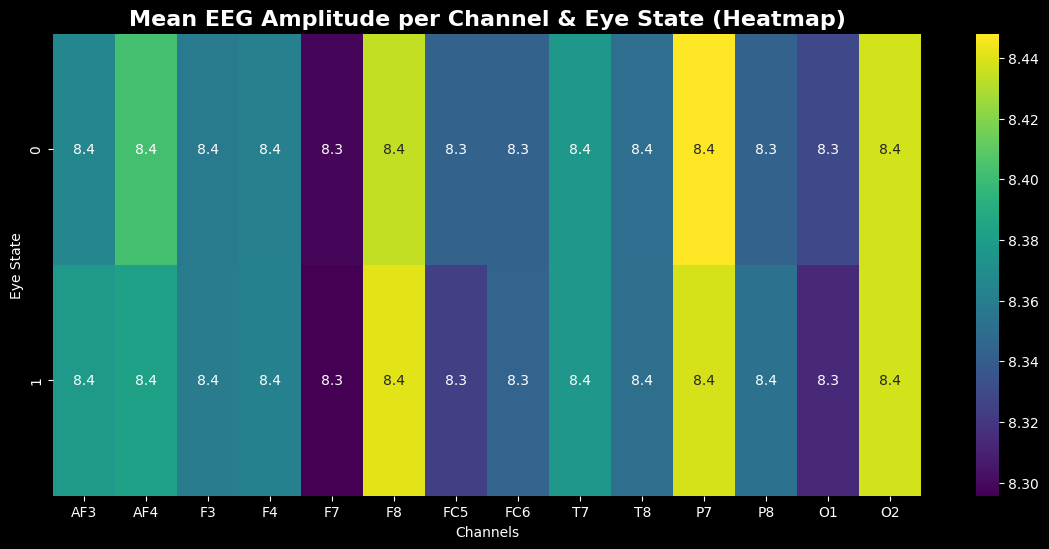

In [13]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    np.log1p(mean_by_state),
    cmap="viridis",
    annot=True
)
plt.title("Mean EEG Amplitude per Channel & Eye State (Heatmap)", fontsize=16, fontweight="bold")
plt.xlabel("Channels")
plt.ylabel("Eye State")
plt.show()

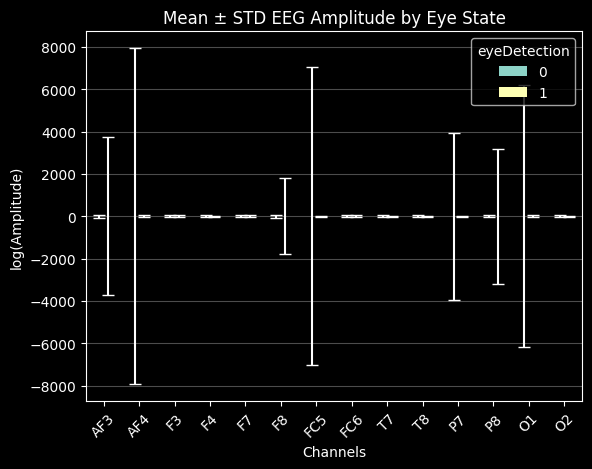

In [14]:
mean_std = data.groupby("eyeDetection")[features].agg(["mean", "std"])
mean_vals = np.log1p(mean_std.xs("mean", level=1, axis=1))
std_vals = mean_std.xs("std", level=1, axis=1)
mean_vals.T.plot(kind="bar", yerr=std_vals.T, capsize=4)
plt.title("Mean ± STD EEG Amplitude by Eye State")
plt.xlabel("Channels")
plt.ylabel("log(Amplitude)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [15]:
eye_counts = data['eyeDetection'].value_counts()
eye_counts

eyeDetection
0    8257
1    6723
Name: count, dtype: int64

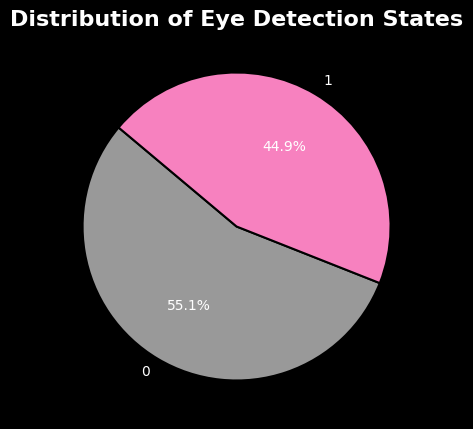

In [16]:
colors = plt.get_cmap('Set1_r').colors[:len(eye_counts)]
plt.figure(figsize=(5,5))
plt.pie(
    eye_counts,
    labels=eye_counts.index,
    autopct="%1.1f%%",   
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'k', 'linewidth':1.5}
)
plt.title("Distribution of Eye Detection States", fontsize=16, fontweight="bold")
plt.show()

In [17]:
for col in features:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

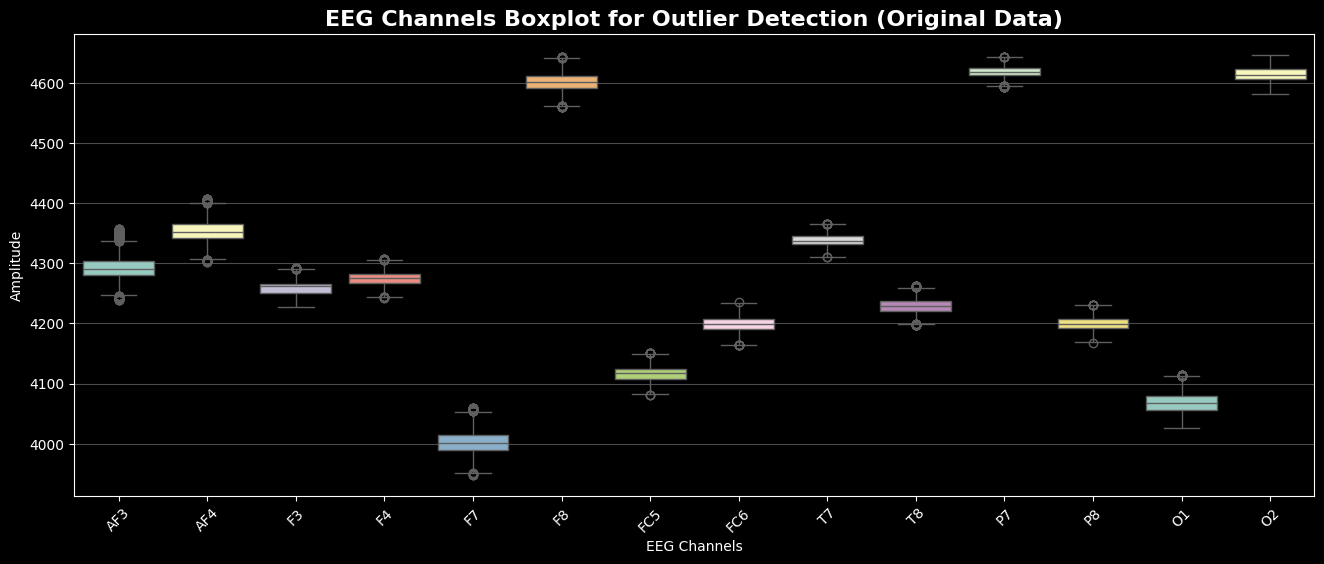

In [18]:
plt.figure(figsize=(16,6))
sns.boxplot(data=data[features], palette="Set3")
plt.title("EEG Channels Boxplot for Outlier Detection (Original Data)", fontsize=16, fontweight="bold")
plt.xlabel("EEG Channels")
plt.ylabel("Amplitude")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

**Preprocessing**

In [19]:
corr = data.corr()
corr

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
AF3,1.000000,0.846194,0.623201,0.634708,0.412966,0.512686,0.416633,0.409708,0.253507,0.412267,0.167322,0.199097,0.256008,0.105257,0.164981
AF4,0.846194,1.000000,0.565057,0.705611,0.223170,0.588905,0.265145,0.498729,0.198620,0.512230,0.180124,0.278207,0.293695,0.223659,0.175601
F3,0.623201,0.565057,1.000000,0.651965,0.302243,0.394720,0.517710,0.391358,0.283836,0.341341,0.258925,0.251324,0.174688,0.262684,0.071742
F4,0.634708,0.705611,0.651965,1.000000,0.126779,0.575551,0.274151,0.580630,0.184160,0.540053,0.273846,0.468720,0.399776,0.408909,0.084198
F7,0.412966,0.223170,0.302243,0.126779,1.000000,0.202636,0.517077,0.117059,0.406571,0.057428,0.215282,0.027861,0.143862,-0.133718,-0.063586
F8,0.512686,0.588905,0.394720,0.575551,0.202636,1.000000,0.228106,0.575229,0.293320,0.528301,0.277678,0.353671,0.195502,0.211298,0.095213
FC5,0.416633,0.265145,0.517710,0.274151,0.517077,0.228106,1.000000,0.197893,0.386425,0.122239,0.239805,0.074663,0.081263,-0.011039,-0.045761
FC6,0.409708,0.498729,0.391358,0.580630,0.117059,0.575229,0.197893,1.000000,0.354789,0.573174,0.319288,0.442684,0.271209,0.385511,0.028167
T7,0.253507,0.198620,0.283836,0.184160,0.406571,0.293320,0.386425,0.354789,1.000000,0.332005,0.591201,0.261449,0.379771,0.225174,-0.060294
T8,0.412267,0.512230,0.341341,0.540053,0.057428,0.528301,0.122239,0.573174,0.332005,1.000000,0.438003,0.634962,0.268496,0.484976,0.025373


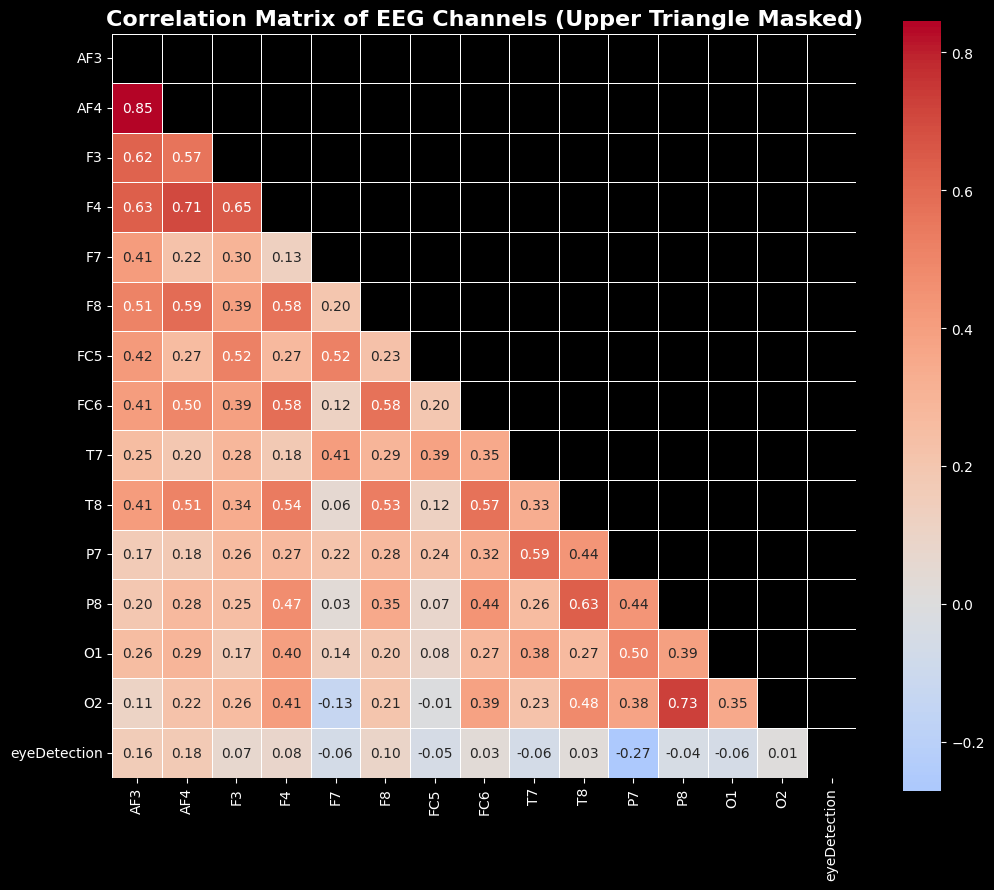

In [20]:
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12,10))
sns.heatmap(
    corr, 
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Correlation Matrix of EEG Channels (Upper Triangle Masked)", fontsize=16, fontweight="bold")
plt.show()

In [21]:
corr_eye = corr[:-1].eyeDetection
corr_eye

AF3    0.164981
AF4    0.175601
F3     0.071742
F4     0.084198
F7    -0.063586
F8     0.095213
FC5   -0.045761
FC6    0.028167
T7    -0.060294
T8     0.025373
P7    -0.270462
P8    -0.042296
O1    -0.055154
O2     0.012286
Name: eyeDetection, dtype: float64

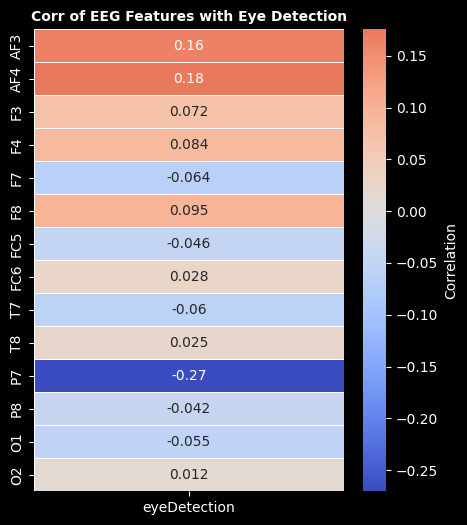

In [22]:
plt.figure(figsize=(5,6))
sns.heatmap(
    corr_eye.to_frame(),   
    annot=True,
    cmap="coolwarm",
    center=0,
    cbar_kws={'label': 'Correlation'},
    linewidths=0.5
)
plt.title("Corr of EEG Features with Eye Detection", fontsize=10, fontweight='bold')
plt.show()

In [23]:
X = data.iloc[:,:-1]
y = data.eyeDetection
X.head() 

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2
50,4305.13,4357.95,4259.49,4261.03,4008.72,4611.79,4120.00,4198.46,4341.03,4219.49,4595.90,4199.49,4092.82,4612.31
51,4293.33,4347.69,4254.36,4252.82,3994.87,4597.95,4116.41,4186.67,4337.44,4211.79,4596.41,4193.33,4092.31,4609.74
52,4297.44,4350.77,4258.46,4260.51,3994.36,4602.05,4118.97,4192.31,4336.92,4209.74,4594.36,4193.33,4096.92,4614.36
53,4308.21,4374.87,4268.21,4271.79,4007.18,4614.36,4126.15,4205.13,4344.62,4221.54,4595.38,4205.13,4102.05,4622.56
57,4324.62,4388.72,4276.41,4276.92,4018.97,4632.82,4135.90,4216.41,4341.54,4242.05,4600.51,4211.28,4099.49,4626.15


In [24]:
y.head()

50    0
51    0
52    0
53    0
57    0
Name: eyeDetection, dtype: int64

In [25]:
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X),columns=features)
X.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2
0,0.556507,0.532033,0.496085,0.277821,0.546316,0.625673,0.551477,0.489198,0.551485,0.346538,0.060666,0.500000,0.760205,0.480344
1,0.456465,0.433484,0.417319,0.150751,0.421271,0.460103,0.500000,0.323793,0.486058,0.228313,0.070711,0.401535,0.754390,0.440878
2,0.491310,0.463068,0.480270,0.269772,0.416667,0.509152,0.536708,0.402918,0.476581,0.196837,0.030333,0.401535,0.806956,0.511824
3,0.582620,0.694554,0.629971,0.444358,0.532412,0.656418,0.639662,0.582772,0.616913,0.378013,0.050423,0.590153,0.865450,0.637746
4,0.721747,0.827586,0.755873,0.523758,0.638859,0.877258,0.779467,0.741021,0.560780,0.692922,0.151467,0.688459,0.836260,0.692875


In [26]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,shuffle=True,random_state=42)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (8615, 14), X_test: (2154, 14), y_train: (8615,), y_test: (2154,)


**ML Models**

In [27]:
models_params = {

    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "solver": ["lbfgs", "liblinear"]
        }
    },

    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [None, 5, 10, 20],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 5]
        }
    },

    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_split": [2, 5]
        }
    },

    "XGBoost": {
        "model": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1]
        }
    },

    "CatBoost": {
        "model": CatBoostClassifier(verbose=0, random_state=42),
        "params": {
            "iterations": [300, 500],
            "depth": [6, 8],
            "learning_rate": [0.05, 0.1]
        }
    },

    "LightGBM": {
        "model": LGBMClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 300],
            "learning_rate": [0.05, 0.1],
            "num_leaves": [31, 50]
        }
    }
}
results = []

for name, mp in models_params.items():
    print(f"Training {name} ...")

    grid = GridSearchCV(
        estimator=mp["model"],
        param_grid=mp["params"],
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Best Estimator": best_model,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df


Training Logistic Regression ...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Training Decision Tree ...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Training Random Forest ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Training XGBoost ...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:47:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:47:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:47:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:47:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [10:47:50] WARNING: /w

Training CatBoost ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Training LightGBM ...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LightGBM] [Info] Number of positive: 3064, number of negative: 3828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 6892, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444573 -> initscore=-0.222621
[LightGBM] [Info] Start training from score -0.222621


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[LightGBM] [Info] Number of positive: 3064, number of negative: 3828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001044 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1998
[LightGBM] [Info] Number of data points in the train set: 6892, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444573 -> initscore=-0.222621
[LightGBM] [Info] Start training from score -0.222621
[LightGBM] [Info] Number of positive: 3064, number of negative: 3828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2003
[LightGBM] [Info] Number of data points in the train set: 6892, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.444573 -> initscore=-0.222621
[LightGBM] [Info] Start training from score -0.222621
[LightGBM] [Info] 

,Model,Best Params,Best Estimator,Accuracy
4,CatBoost,"{'depth': 8, 'iterations': 500, 'learning_rate...",<catboost.core.CatBoostClassifier object at 0x...,0.953575
5,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 300, 'n...","LGBMClassifier(n_estimators=300, num_leaves=50...",0.941504
3,XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...","XGBClassifier(base_score=None, booster=None, c...",0.930826
2,Random Forest,"{'max_depth': 20, 'min_samples_split': 2, 'n_e...","(DecisionTreeClassifier(max_depth=20, max_feat...",0.911328
1,Decision Tree,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...","DecisionTreeClassifier(min_samples_leaf=2, ran...",0.813835
0,Logistic Regression,"{'C': 1, 'solver': 'lbfgs'}","LogisticRegression(C=1, max_iter=1000)",0.684308


In [28]:
best_model = results_df.iloc[0]["Best Estimator"]
y_pred = best_model.predict(X_test)

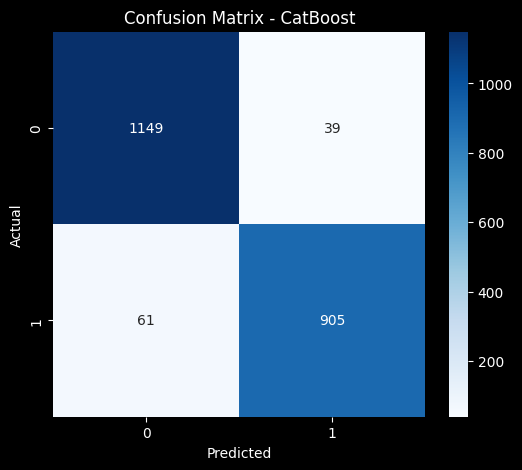

array([[1149,   39],
       [  61,  905]])

In [29]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {results_df.iloc[0]['Model']}")
plt.show()
cm

In [30]:
print(f"Classification Report for {results_df.iloc[0]['Model']}:\n")
print(classification_report(y_test,y_pred))

Classification Report for CatBoost:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1188
           1       0.96      0.94      0.95       966

    accuracy                           0.95      2154
   macro avg       0.95      0.95      0.95      2154
weighted avg       0.95      0.95      0.95      2154

